# Ridge Regresija — Predikcija Cena Automobila

## Struktura
1. Data Loading & Overview
2. Feature Engineering (outlier check, ciklični mesec, drop g_km)
3. Train/Test Split + Log transformacija
4. Preprocessing Pipeline
5. Baseline Model
6. Ridge + GridSearchCV
7. Evaluacija i Vizualizacije
8. Interpretacija Koeficijenata
9. Čuvanje Pipeline-a
10. PCA Eksperiment

## 1. Data Loading & Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
np.random.seed(42)

BASE_DIR = Path.cwd()
PROCESSED_DATA_PATH = BASE_DIR.parent / "DataSet" / "processed" / "procesirani_podaci.csv"
MODELS_DIR = BASE_DIR.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Kolone: {list(df.columns)}")
df.head()

Dataset shape: (239844, 13)
Kolone: ['brand', 'model', 'color', 'year', 'price_in_euro', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age']


,brand,model,color,year,price_in_euro,power_kw,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
0,alfa-romeo,alfa romeo gtv,red,1995.0,1300.0,148.0,manual,petrol,10.9,260.0,160500.0,10.0,31.0
1,alfa-romeo,alfa romeo 164,black,1995.0,24900.0,191.0,manual,petrol,5.7,135.0,190000.0,2.0,31.0
2,alfa-romeo,alfa romeo spider,black,1995.0,4900.0,110.0,manual,petrol,9.5,225.0,189500.0,7.0,31.0
3,alfa-romeo,alfa romeo 164,red,1996.0,17950.0,132.0,manual,petrol,7.2,135.0,96127.0,11.0,30.0
4,alfa-romeo,alfa romeo spider,red,1996.0,7900.0,110.0,manual,petrol,9.5,225.0,47307.0,4.0,30.0


In [2]:
print('── Tipovi podataka ──────────────────────────')
print(df.dtypes)
print()
print('── Nedostajuće vrednosti ────────────────────')
print(df.isnull().sum())
print()
print('── Osnovna statistika ───────────────────────')
df.describe().round(2)

── Tipovi podataka ──────────────────────────
brand                           str
model                           str
color                           str
year                        float64
price_in_euro               float64
power_kw                    float64
transmission_type               str
fuel_type                       str
fuel_consumption_l_100km    float64
fuel_consumption_g_km       float64
mileage_in_km               float64
registration_month          float64
car_age                     float64
dtype: object

── Nedostajuće vrednosti ────────────────────
brand                       0
model                       0
color                       0
year                        0
price_in_euro               0
power_kw                    0
transmission_type           0
fuel_type                   0
fuel_consumption_l_100km    0
fuel_consumption_g_km       0
mileage_in_km               0
registration_month          0
car_age                     0
dtype: int64

── Osnovna statistika

,year,price_in_euro,power_kw,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
count,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00
mean,2016.12,24936.46,125.80,6.02,141.25,87019.75,6.30,9.88
std,5.45,25141.76,69.73,1.80,55.37,75092.81,3.38,5.45
min,1995.00,500.00,25.00,0.50,0.00,0.00,1.00,3.00
25%,2013.00,11900.00,84.00,5.00,119.00,27408.75,3.00,6.00
50%,2018.00,19500.00,110.00,5.70,135.00,69978.00,6.00,8.00
75%,2020.00,29850.00,140.00,6.60,157.00,129000.00,9.00,13.00
max,2023.00,300000.00,596.00,30.00,2018.00,500000.00,12.00,31.00


In [3]:
print(f"Transmission types ({df['transmission_type'].nunique()}): {df['transmission_type'].unique().tolist()}")
print(f"Fuel types ({df['fuel_type'].nunique()}): {df['fuel_type'].unique().tolist()}")
print(f"Colors:  {df['color'].nunique()} jedinstvenih")
print(f"Brands:  {df['brand'].nunique()} jedinstvenih")
print(f"Models:  {df['model'].nunique()} jedinstvenih")

Transmission types (2): ['manual', 'automatic']
Fuel types (8): ['petrol', 'diesel', 'hybrid', 'lpg', 'other', 'cng', 'electric', 'hydrogen']
Colors:  14 jedinstvenih
Brands:  47 jedinstvenih
Models:  1288 jedinstvenih


## 2. Feature Engineering

1. **`year` uklonjen** — `car_age` nosi istu informaciju (identično v1)
2. **`fuel_consumption_g_km` uklonjen** — NOVO: visoka korelacija sa `l/100km`
3. **`registration_month` → `month_sin` + `month_cos`** — NOVO: ciklična varijabla

In [5]:
if 'year' in df.columns:
    df = df.drop(columns=['year'])
    print("'year' uklonjen — zadrzavamo samo 'car_age'")
print(f"Shape: {df.shape}")

Shape: (239844, 12)


In [6]:
print('── Provera anomalija: fuel_consumption_g_km > 500 ──')
anomalije = df[df['fuel_consumption_g_km'] > 500]
print(f"Broj redova sa g_km > 500: {len(anomalije)}")
if len(anomalije) > 0:
    print(anomalije[['brand', 'model', 'fuel_consumption_g_km', 'fuel_consumption_l_100km']].head(10))

print()
corr = df['fuel_consumption_l_100km'].corr(df['fuel_consumption_g_km'])
print(f"Pearsonova korelacija l/100km vs g/km: {corr:.4f} — prakticno ista informacija")

# Drop redundantne kolone
df = df.drop(columns=['fuel_consumption_g_km'])
print("\n'fuel_consumption_g_km' uklonjen.")
print(f"Shape: {df.shape}")

── Provera anomalija: fuel_consumption_g_km > 500 ──
Broj redova sa g_km > 500: 242
      brand           model  fuel_consumption_g_km  fuel_consumption_l_100km
20210  audi            audi                  501.0                       5.7
21221  audi  audi q4 e-tron                  530.0                       5.7
21555  audi            audi                  542.0                       5.7
21645  audi  audi q8 e-tron                  518.0                       5.7
21953  audi     audi e-tron                  505.0                       5.7
21986  audi         audi q8                  541.0                       5.7
21990  audi  audi q8 e-tron                  505.0                       5.7
22116  audi         audi q8                  525.0                       5.7
22133  audi  audi q8 e-tron                  519.0                       5.7
22159  audi         audi q8                  541.0                       5.7

Pearsonova korelacija l/100km vs g/km: 0.6602 — prakticno ista infor

In [7]:
# IZMENA 3: Ciklicno kodiranje registration_month
# Mesec 1 i mesec 12 su blizu ali bi linearno bili daleko (1 vs 12)
# sin/cos encoding cuva ciklicnu prirodu
df['month_sin'] = np.sin(2 * np.pi * df['registration_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['registration_month'] / 12)
df = df.drop(columns=['registration_month'])

print('registration_month → month_sin + month_cos (ciklicno encoding)')
print(f'Shape: {df.shape}')
print(f'Kolone: {list(df.columns)}')

registration_month → month_sin + month_cos (ciklicno encoding)
Shape: (239844, 12)
Kolone: ['brand', 'model', 'color', 'price_in_euro', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'mileage_in_km', 'car_age', 'month_sin', 'month_cos']


## 3. Train/Test Split + Log-transformacija targeta

### Zasto log(price)?

| Problem u v1 | Uzrok | Fix |
|---|---|---|
| Negativne predikcije | Cena je log-normalna, Ridge je linearan | `y = log(price)` → uvek pozitivna predikcija |
| Heteroskedaticnost | Varijansa greske raste sa cenom | Log normalizuje varijansu po celom opsegu |
| Slabije metrike za skupe aute | Model optimizuje apsolutnu gresku | Log daje proporcionalne greske |

**Workflow:**
```
fit:      model.fit(X_train, log(y_train))
predict:  y_pred_eur = exp(model.predict(X_test))
```

In [8]:
TARGET = 'price_in_euro'

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train_log = np.log(y_train)   # modeli treniraju na ovome
y_test_log  = np.log(y_test)    # za R² u log prostoru (dijagnostika)

print(f"X_train: {X_train.shape}   ({len(X_train)/len(X)*100:.1f}%)")
print(f"X_test:  {X_test.shape}   ({len(X_test)/len(X)*100:.1f}%)")
print()
print(f"y_train mean (EUR):     {y_train.mean():>10,.2f}")
print(f"y_train mean (log EUR): {y_train_log.mean():>10.4f}")
print(f"y_test  mean (EUR):     {y_test.mean():>10,.2f}")
print()
print(f"Provera: min y_train = {y_train.min():.2f} EUR  → log = {np.log(y_train.min()):.4f}  (uvek pozitivno po exp())")
print(f"Kolone X_train: {list(X_train.columns)}")

X_train: (191875, 11)   (80.0%)
X_test:  (47969, 11)   (20.0%)

y_train mean (EUR):      24,908.90
y_train mean (log EUR):     9.7958
y_test  mean (EUR):      25,046.71

Provera: min y_train = 500.00 EUR  → log = 6.2146  (uvek pozitivno po exp())
Kolone X_train: ['brand', 'model', 'color', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'mileage_in_km', 'car_age', 'month_sin', 'month_cos']


## 4. Preprocessing Pipeline

| Grupa | Transformer(i) | Razlog |
|---|---|---|
| `brand`, `model` | `TargetEncoder` + `StandardScaler` | Visoka kardinalnost |
| `transmission_type`, `fuel_type`, `color` | `OneHotEncoder` | Niska kardinalnost, binarne vrednosti |
| Numericke + `month_sin/cos` | `StandardScaler` | Razlicite skale |

**Izmena v2:** NUM_COLS automatski uključuje `month_sin`/`month_cos`, ne uključuje `fuel_consumption_g_km`.

In [9]:
TARGET_ENC_COLS = ['brand', 'model']
OHE_COLS        = ['transmission_type', 'fuel_type', 'color']
NUM_COLS        = [c for c in X_train.columns
                   if c not in TARGET_ENC_COLS + OHE_COLS]

print('Target Encoded:', TARGET_ENC_COLS)
print('One-Hot Encoded:', OHE_COLS)
print('Numericki (StandardScaler):', NUM_COLS)
print(f'\nUkupno: {len(TARGET_ENC_COLS)} TE + {len(OHE_COLS)} OHE grupe + {len(NUM_COLS)} numerickih')

Target Encoded: ['brand', 'model']
One-Hot Encoded: ['transmission_type', 'fuel_type', 'color']
Numericki (StandardScaler): ['power_kw', 'fuel_consumption_l_100km', 'mileage_in_km', 'car_age', 'month_sin', 'month_cos']

Ukupno: 2 TE + 3 OHE grupe + 6 numerickih


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc',
         Pipeline([
             ('encoder', TargetEncoder(target_type='continuous')),
             ('scaler',  StandardScaler()),
         ]),
         TARGET_ENC_COLS),

        ('ohe',
         OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False),
         OHE_COLS),

        ('num_scaler',
         StandardScaler(),
         NUM_COLS),
    ],
    remainder='drop'
)

print('ColumnTransformer definisan:')
print('  target_enc  → TargetEncoder + StandardScaler  (brand, model)')
print('  ohe         → OneHotEncoder [bez skaliranja]  (transmission_type, fuel_type, color)')
print('  num_scaler  → StandardScaler                  (numericke + month_sin/cos)')

ColumnTransformer definisan:
  target_enc  → TargetEncoder + StandardScaler  (brand, model)
  ohe         → OneHotEncoder [bez skaliranja]  (transmission_type, fuel_type, color)
  num_scaler  → StandardScaler                  (numericke + month_sin/cos)


## 5. Baseline Model — LinearRegression

###### fit na `y_train_log`, predikcije vraćene u EUR sa `np.exp()`.

In [11]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# IZMENA: fit na log targetu
baseline_pipeline.fit(X_train, y_train_log)
y_pred_baseline_log = baseline_pipeline.predict(X_test)
y_pred_baseline     = np.exp(y_pred_baseline_log)   # vrati u EUR

baseline_mae  = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2   = r2_score(y_test, y_pred_baseline)

print('── Baseline: LinearRegression (log target → EUR) ────')
print(f'  MAE  : {baseline_mae:>10,.2f} EUR')
print(f'  RMSE : {baseline_rmse:>10,.2f} EUR')
print(f'  R²   : {baseline_r2:>10.4f}')
print(f'  Min predikcije: {y_pred_baseline.min():,.2f} EUR  ← mora biti > 0')

── Baseline: LinearRegression (log target → EUR) ────
  MAE  :   4,844.33 EUR
  RMSE :  10,402.85 EUR
  R²   :     0.8311
  Min predikcije: 721.12 EUR  ← mora biti > 0


## 6. Ridge Regresija + GridSearchCV Tuning

#### `grid_search.fit(X_train, y_train_log)` — treniramo na log skali.

In [12]:
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
}

grid_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# IZMENA: fit na log targetu
grid_search.fit(X_train, y_train_log)

best_alpha = grid_search.best_params_['model__alpha']
best_cv_r2 = grid_search.best_score_
print(f'\nNajbolji alpha:  {best_alpha}')
print(f'Najbolji CV R² (log prostor): {best_cv_r2:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Najbolji alpha:  0.1
Najbolji CV R² (log prostor): 0.8661


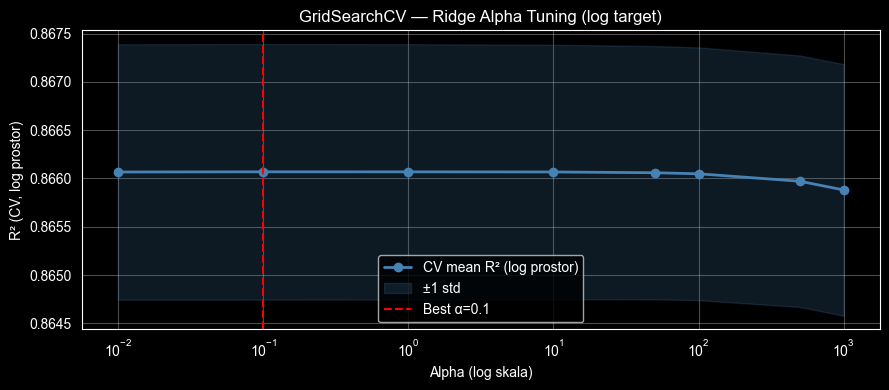

In [14]:
cv_results = pd.DataFrame(grid_search.cv_results_)
alphas     = cv_results['param_model__alpha'].astype(float)
mean_r2    = cv_results['mean_test_score']
std_r2     = cv_results['std_test_score']

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(alphas, mean_r2, 'o-', color='steelblue', linewidth=2, label='CV mean R² (log prostor)')
ax.fill_between(alphas, mean_r2 - std_r2, mean_r2 + std_r2,
                alpha=0.2, color='steelblue', label='±1 std')
ax.axvline(best_alpha, color='red', linestyle='--', label=f'Best α={best_alpha}')
ax.set_xlabel('Alpha (log skala)')
ax.set_ylabel('R² (CV, log prostor)')
ax.set_title('GridSearchCV — Ridge Alpha Tuning (log target)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_alpha_tuning.png', dpi=150)
plt.show()

## 7. Evaluacija i Vizualizacije

In [15]:
best_pipeline = grid_search.best_estimator_
y_pred_log = best_pipeline.predict(X_test)
y_pred     = np.exp(y_pred_log)

ridge_mae    = mean_absolute_error(y_test, y_pred)
ridge_rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
ridge_r2     = r2_score(y_test, y_pred)
ridge_r2_log = r2_score(y_test_log, y_pred_log)   # dijagnostika

print('── Evaluacija na TEST skupu (predikcije u EUR) ───────')
print(f'  MAE             : {ridge_mae:>10,.2f} EUR')
print(f'  RMSE            : {ridge_rmse:>10,.2f} EUR')
print(f'  R² (EUR prostor): {ridge_r2:>10.4f}')
print(f'  R² (log prostor): {ridge_r2_log:>10.4f}')
print()
print(f'  Min predikcije: {y_pred.min():,.2f} EUR  ← mora biti > 0')
print(f'  Max predikcije: {y_pred.max():,.2f} EUR')
print()
print('── Poređenje sa Baseline ────────────────────')
print(f"{'':25s} {'Baseline':>12s} {'Ridge':>12s} {'Poboljšanje':>14s}")
print(f"{'MAE':25s} {baseline_mae:>12,.2f} {ridge_mae:>12,.2f} {baseline_mae - ridge_mae:>+14,.2f}")
print(f"{'RMSE':25s} {baseline_rmse:>12,.2f} {ridge_rmse:>12,.2f} {baseline_rmse - ridge_rmse:>+14,.2f}")
print(f"{'R²':25s} {baseline_r2:>12.4f} {ridge_r2:>12.4f} {ridge_r2 - baseline_r2:>+14.4f}")

── Evaluacija na TEST skupu (predikcije u EUR) ───────
  MAE             :   4,843.62 EUR
  RMSE            :  10,398.54 EUR
  R² (EUR prostor):     0.8313
  R² (log prostor):     0.8677

  Min predikcije: 720.81 EUR  ← mora biti > 0
  Max predikcije: 489,859.61 EUR

── Poređenje sa Baseline ────────────────────
                              Baseline        Ridge    Poboljšanje
MAE                           4,844.33     4,843.62          +0.72
RMSE                         10,402.85    10,398.54          +4.31
R²                              0.8311       0.8313        +0.0001


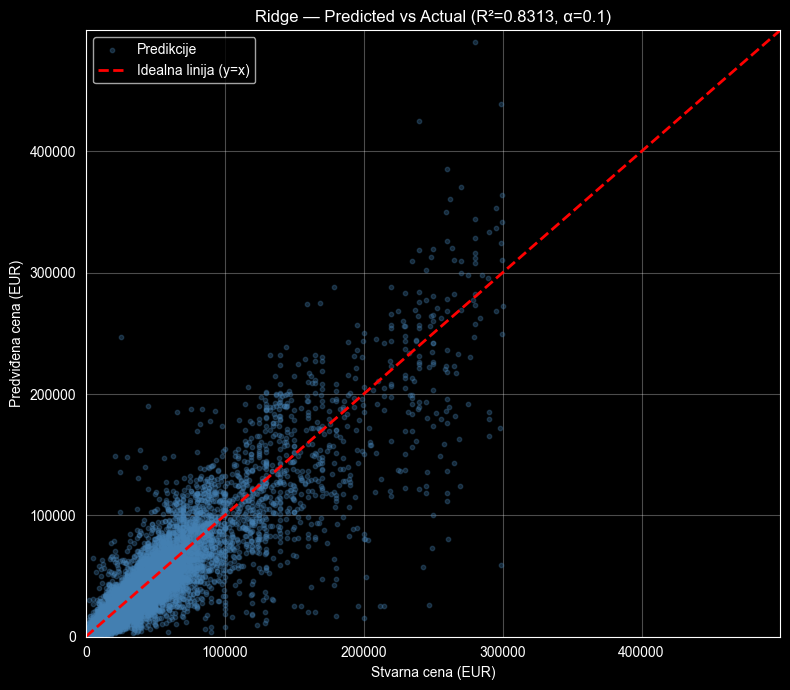

In [16]:
# Grafik 1: Predicted vs Actual
fig, ax = plt.subplots(figsize=(8, 7))

max_val = max(y_test.max(), y_pred.max()) * 1.02

ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue', label='Predikcije')
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Idealna linija (y=x)')

# IZMENA: ose pocinju od 0
ax.set_xlim(left=0, right=max_val)
ax.set_ylim(bottom=0, top=max_val)

ax.set_xlabel('Stvarna cena (EUR)')
ax.set_ylabel('Predviđena cena (EUR)')
ax.set_title(f'Ridge — Predicted vs Actual (R²={ridge_r2:.4f}, α={best_alpha})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_pred_vs_actual.png', dpi=150)
plt.show()

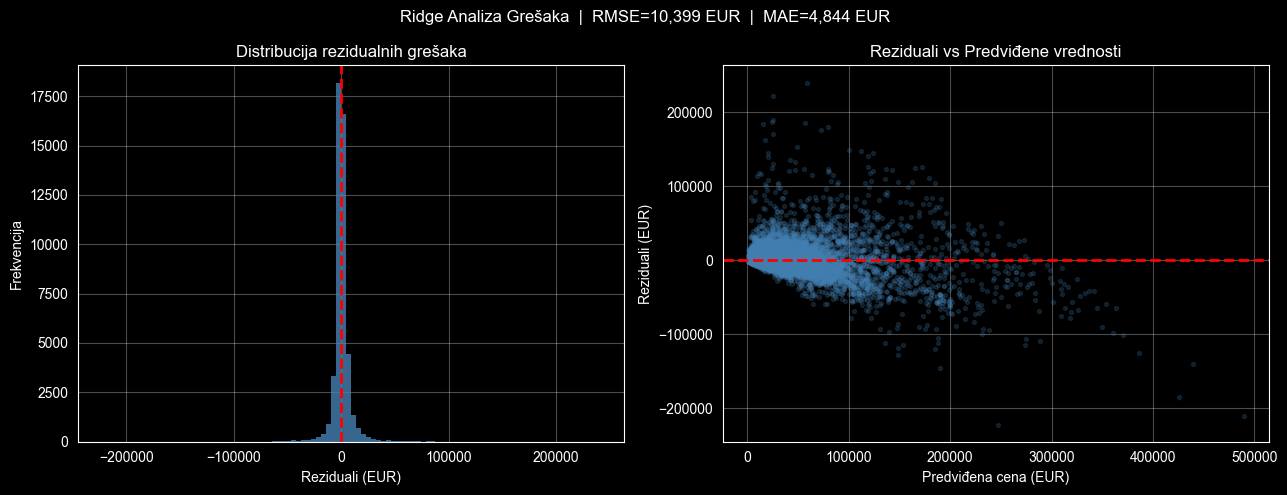

Srednja vrednost rezidualnih grešaka: +537.80 EUR  (treba biti ≈ 0)
Std rezidualnih grešaka:               10,384.73 EUR


In [17]:
# Grafik 2: Reziduali
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Reziduali (EUR)')
axes[0].set_ylabel('Frekvencija')
axes[0].set_title('Distribucija rezidualnih grešaka')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred, residuals, alpha=0.2, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predviđena cena (EUR)')
axes[1].set_ylabel('Reziduali (EUR)')
axes[1].set_title('Reziduali vs Predviđene vrednosti')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Ridge Analiza Grešaka  |  RMSE={ridge_rmse:,.0f} EUR  |  MAE={ridge_mae:,.0f} EUR',
             fontsize=12)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_residuali.png', dpi=150)
plt.show()

print(f'Srednja vrednost rezidualnih grešaka: {residuals.mean():+,.2f} EUR  (treba biti ≈ 0)')
print(f'Std rezidualnih grešaka:              {residuals.std():>10,.2f} EUR')

## 8. Interpretacija Koeficijenata

**Napomena** Koeficijenti su u **log prostoru** (model je treniran na `log(price)`).
Koeficijent od +0.3 znači ~35% veću cenu (`exp(0.3) ≈ 1.35`), a -0.2 znači ~18% manju cenu.

In [18]:
ridge_model = best_pipeline.named_steps['model']
prep        = best_pipeline.named_steps['preprocessor']

te_names  = TARGET_ENC_COLS
ohe_names = list(prep.named_transformers_['ohe'].get_feature_names_out(OHE_COLS))
num_names = NUM_COLS

all_feature_names = te_names + ohe_names + num_names
coef = ridge_model.coef_

coef_df = pd.DataFrame({
    'Feature':     all_feature_names,
    'Koeficijent': coef,
    'Exp_koef':    np.exp(coef),
    'Uticaj_pct':  (np.exp(coef) - 1) * 100
}).sort_values('Koeficijent', key=abs, ascending=False)

print(f'Broj feature-a: {len(all_feature_names)}')
print(f'Intercept (log EUR): {ridge_model.intercept_:.4f}  → exp = {np.exp(ridge_model.intercept_):,.2f} EUR')
print()
print('Top 15 feature-a:')
print(coef_df[['Feature', 'Koeficijent', 'Exp_koef', 'Uticaj_pct']].head(15).to_string(index=False))

Broj feature-a: 29
Intercept (log EUR): 9.8580  → exp = 19,109.69 EUR

Top 15 feature-a:
                 Feature  Koeficijent  Exp_koef  Uticaj_pct
                 car_age    -0.336482  0.714279  -28.572093
                power_kw     0.258508  1.294996   29.499616
           mileage_in_km    -0.234825  0.790709  -20.929064
        fuel_type_diesel     0.224007  1.251080   25.107960
      fuel_type_hydrogen     0.189018  1.208063   20.806258
         fuel_type_other     0.177502  1.194230   19.422999
                   model     0.163393  1.177499   17.749887
transmission_type_manual    -0.150890  0.859942  -14.005782
           fuel_type_lpg    -0.109957  0.895873  -10.412738
              color_blue    -0.083640  0.919762   -8.023769
             color_black    -0.080517  0.922639   -7.736092
              color_grey    -0.078242  0.924741   -7.525949
      fuel_type_electric    -0.077136  0.925764   -7.423610
               color_red    -0.074194  0.928491   -7.150891
           

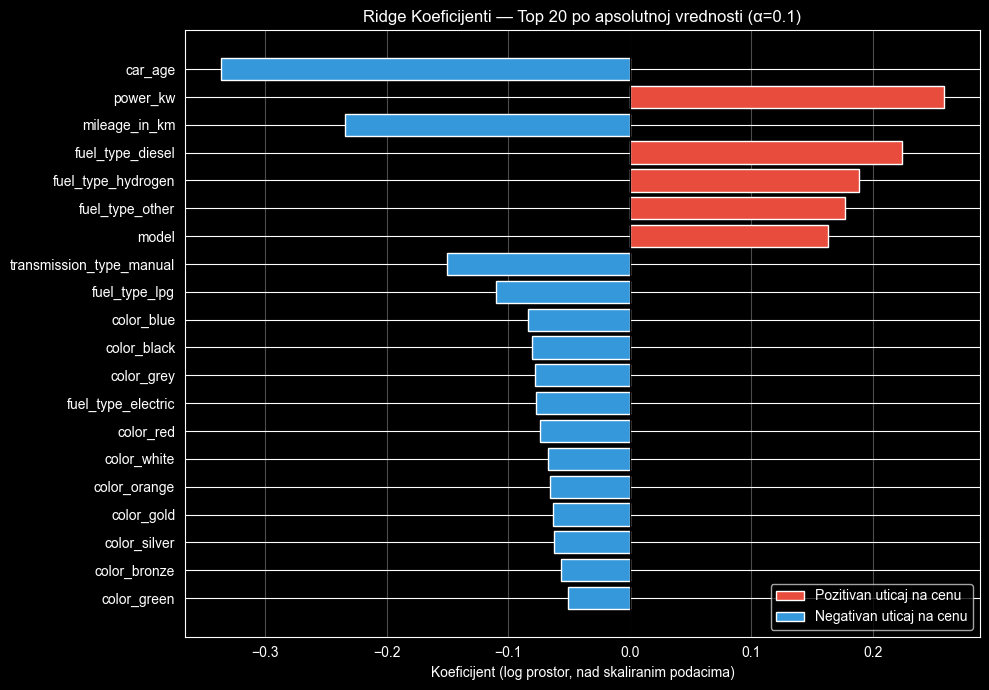


Napomena (log prostor):
  exp(koef) = multiplikator cene
  Primer: koef=+0.3 → cena ~35% veca (exp(0.3)=1.35)
  Primer: koef=-0.2 → cena ~18% manja (exp(-0.2)=0.82)


In [19]:
top_n    = 20
top_coef = coef_df.head(top_n)
colors   = ['#e74c3c' if v > 0 else '#3498db' for v in top_coef['Koeficijent']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_coef['Feature'], top_coef['Koeficijent'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Koeficijent (log prostor, nad skaliranim podacima)')
ax.set_title(f'Ridge Koeficijenti — Top {top_n} po apsolutnoj vrednosti (α={best_alpha})')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Pozitivan uticaj na cenu'),
                   Patch(facecolor='#3498db', label='Negativan uticaj na cenu')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_koeficijenti.png', dpi=150)
plt.show()

print()
print('Napomena (log prostor):')
print('  exp(koef) = multiplikator cene')
print('  Primer: koef=+0.3 → cena ~35% veca (exp(0.3)=1.35)')
print('  Primer: koef=-0.2 → cena ~18% manja (exp(-0.2)=0.82)')

## 9. Čuvanje Celog Pipeline-a

In [20]:
pipeline_path = MODELS_DIR / 'ridge_full_pipeline_v2.pkl'
joblib.dump(best_pipeline, pipeline_path)
print(f'Pipeline sacuvan: {pipeline_path}')
# Verifikacija
loaded_pipeline = joblib.load(pipeline_path)
y_pred_verify   = np.exp(loaded_pipeline.predict(X_test))
r2_verify       = r2_score(y_test, y_pred_verify)
status = '✓' if abs(r2_verify - ridge_r2) < 1e-6 else 'NEUSPELA!'
print(f'\nVerifikacija (R² na test skupu, reload): {r2_verify:.4f}  {status}')

Pipeline sacuvan: D:\Work\used-car-price-prediction\models\ridge_full_pipeline_v2.pkl

Verifikacija (R² na test skupu, reload): 0.8313  ✓


## 10. PCA Eksperiment

**Izmena** PCA pipeline treniran na `y_train_log`, predikcije vraćene u EUR.

In [21]:
pca_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca',          PCA(n_components=0.95, random_state=42)),
    ('model',        Ridge(alpha=best_alpha))
])

# IZMENA: fit na log targetu
pca_pipeline.fit(X_train, y_train_log)
y_pred_pca_log = pca_pipeline.predict(X_test)
y_pred_pca     = np.exp(y_pred_pca_log)   # vrati u EUR

pca_r2    = r2_score(y_test, y_pred_pca)
pca_mae   = mean_absolute_error(y_test, y_pred_pca)
pca_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_pca))
n_components = pca_pipeline.named_steps['pca'].n_components_

print(f'PCA komponente (95% varijanse): {n_components}')
print()
print('── Poređenje: Originalni prostor vs PCA ─────')
print(f"{'':20s} {'Original':>12s} {'PCA':>12s}")
print(f"{'MAE':20s} {ridge_mae:>12,.2f} {pca_mae:>12,.2f}")
print(f"{'RMSE':20s} {ridge_rmse:>12,.2f} {pca_rmse:>12,.2f}")
print(f"{'R²':20s} {ridge_r2:>12.4f} {pca_r2:>12.4f}")
print()
diff = ridge_r2 - pca_r2
print(f"Zakljucak: PCA model je {'losiji' if diff > 0 else 'bolji'} za ΔR²={abs(diff):.4f}")
print('→ Finalni model: Ridge u ORIGINALNOM prostoru feature-a.')

PCA komponente (95% varijanse): 13

── Poređenje: Originalni prostor vs PCA ─────
                         Original          PCA
MAE                      4,843.62     4,959.55
RMSE                    10,398.54    10,678.61
R²                         0.8313       0.8221

Zakljucak: PCA model je losiji za ΔR²=0.0092
→ Finalni model: Ridge u ORIGINALNOM prostoru feature-a.


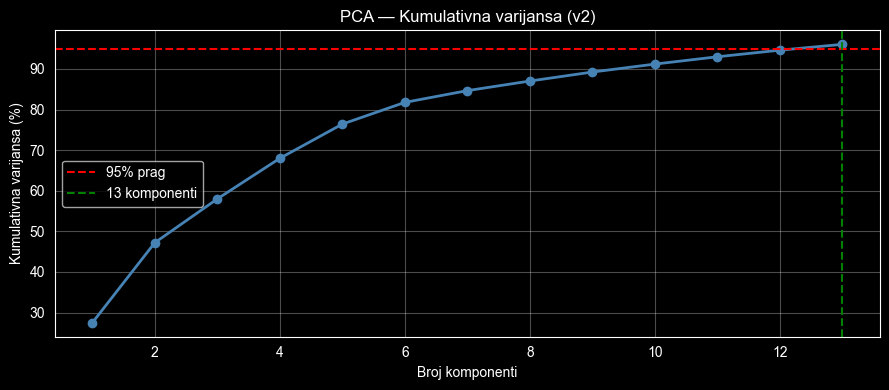

In [22]:
pca_step = pca_pipeline.named_steps['pca']
cumvar   = np.cumsum(pca_step.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, 'o-', color='steelblue', linewidth=2)
ax.axhline(95, color='red', linestyle='--', label='95% prag')
ax.axvline(n_components, color='green', linestyle='--', label=f'{n_components} komponenti')
ax.set_xlabel('Broj komponenti')
ax.set_ylabel('Kumulativna varijansa (%)')
ax.set_title('PCA — Kumulativna varijansa (v2)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ridge_pca_varijansa.png', dpi=150)
plt.show()